# EEG Trigger Press · LightGBM + Engineered Features
## Focused Analysis with Rich Visualizations

Best pipeline from `eeg_pipeline_v2`: **LightGBM on temporal + frequency features**,
LOTO cross-validation, AP-optimised threshold.

**Visualizations**
1. Per-trial probability timeline — model score vs true horizon labels across each full trial
2. Event-related probability — average score trace locked to each press event (ERP-style)
3. Press event zoom gallery — individual 3 s windows around each detected press
4. Per-fold AUC / AP / EvtSens bar chart
5. ROC & Precision-Recall curves
6. Feature importance (mean across LOTO folds)


## 1 · Imports

In [1]:
import warnings

warnings.filterwarnings("ignore")
import os
import sys

import lightgbm as lgb
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from scipy.signal import welch
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

sys.path.insert(0, "..")
from src.postproc import event_detection_metrics, persistence_gate
from src.preprocessing import (
    build_windows,
    euclidean_align,
    load_trial,
    make_horizon_labels,
    make_post_press_mask,
)

optuna.logging.set_verbosity(optuna.logging.WARNING)

DARK, CARD, EDGE = "#0a0e17", "#111827", "#1f2937"
TEAL, CORAL, GOLD, WHITE = "#00e5cc", "#ff4f5e", "#ffc947", "#f0f4ff"
LIME, PURPLE = "#a8ff3e", "#c084fc"

print("Imports OK  (LightGBM", lgb.__version__, ")")

Imports OK  (LightGBM 4.6.0 )


## 2 · Config

In [5]:
SUBJECT =18
TACHE = "way"
ALL_TRIALS = list(range(6))
TEST_TRIALS = list(
    range(6)
)  # list(range(10))  # trial 0 is calibration — always in train
DATA_PATH = f"../data/subject{SUBJECT}/"

# Auto-detect sampling rate from first trial timestamps
_first = f"../data/subject{SUBJECT}/subject_{SUBJECT}_tache_{TACHE}_trial_0.csv"
_ts = pd.read_csv(_first, sep=None, engine="python", usecols=["timestamp"])[
    "timestamp"
].values
FS_RAW = round(len(_ts) / (_ts[-1] - _ts[0]))
DECIM = 4 if FS_RAW >= 100 else 1
FS = FS_RAW
FS_EFF = FS // DECIM
print(f"Detected FS={FS_RAW} Hz  DECIM={DECIM}  FS_EFF={FS_EFF} Hz") 

LP, HP = 0.5, 28.0
HORIZON = int(.8 * FS_EFF)  # 1 s look-ahead
TARGET = "button"
T_MAX = int(1.0 * FS_EFF)  # upper bound for T search
T_MIN = int(0.2 * FS_EFF)  # lower bound for T search

USE_EA = False  # Euclidean Alignment; set False to train/evaluate without it
USE_MF = False  # Matched-filter features; set False to skip MF (use if MF hurts AUC)

MASK_DRONE_ONSET = False  # blank drone-onset VEP windows from training negatives
DRONE_ONSET_LAG_S = 2.5   # seconds before press that the drone appears
VEP_DUR_MS = 600          # ms to blank after drone onset (covers P1→P3)

DESPIKE_SIGMA = 5.0
SKIP_SECONDS = 20.0

MIN_SPEC = 0.90
TARGET_EVT_SENS = 0.7  # operating threshold auto-selected at this sensitivity
SMOOTH_WIN = max(1, int(0.1 * FS_EFF))  # 100 ms
REFRACTORY = 1#int(1.0 * FS_EFF)
PERSIST_K = 1  # persistence gate: require k consecutive frames above threshold
POST_PRESS_BLANK_MS = 0  # ms after each press to exclude from negative class

N_OPTUNA = 15  # number of Optuna trials (1 = quick test; 50-100 for real search)
N_OPTUNA_JOBS = max(1, (os.cpu_count() or 4) // 2)  # parallel Optuna trials
LGB_JOBS = max(1, (os.cpu_count() or 4) // N_OPTUNA_JOBS)  # LGB threads per trial
TRAIN_CAP = 1_000_000
SEED = 42

print(
    f"FS_EFF={FS_EFF} Hz  T_MAX={T_MAX} samp ({T_MAX/FS_EFF:.1f} s)  "
    f"HORIZON={HORIZON} samp ({HORIZON/FS_EFF*1000:.0f} ms)  "
    f"SMOOTH={SMOOTH_WIN} samp ({SMOOTH_WIN/FS_EFF*1000:.0f} ms)"
)
print(
    f"MIN_SPEC={MIN_SPEC}  REFRACTORY={REFRACTORY} samp ({REFRACTORY/FS_EFF*1000:.0f} ms)  TEST_TRIALS={TEST_TRIALS}"
)
print(
    f"T search: {T_MIN} samp ({T_MIN/FS_EFF*1000:.0f} ms) … {T_MAX} samp ({T_MAX/FS_EFF*1000:.0f} ms)"
)
print(f"USE_EA={USE_EA}")

Detected FS=500 Hz  DECIM=4  FS_EFF=125 Hz
FS_EFF=125 Hz  T_MAX=125 samp (1.0 s)  HORIZON=100 samp (800 ms)  SMOOTH=12 samp (96 ms)
MIN_SPEC=0.9  REFRACTORY=1 samp (8 ms)  TEST_TRIALS=[0, 1, 2, 3, 4, 5]
T search: 25 samp (200 ms) … 125 samp (1000 ms)
USE_EA=False


## 3 · Load & Filter

In [6]:
print("Loading (CAR + trial_zscore + 0.5–28 Hz) …")
raw_data, EEG_COLS = {}, None
led_data = {}

for t in ALL_TRIALS:
    df, cols = load_trial(
        SUBJECT,
        TACHE,
        t,
        DATA_PATH,
        eeg_cols=EEG_COLS,
        fs=FS,
        lp=LP,
        hp=HP,
        decimate=DECIM,
        car=True,
        trial_zscore=True,
        clip_percentile=1.0,
        despike_sigma=DESPIKE_SIGMA,
        skip_seconds=SKIP_SECONDS,
        #channels=[f"ch{ch}" for ch in [2, 3, 4, 10, 11, 12]]#[6, 7, 8, 9, 10, 11, 12]]#[1, 2, 3, 4, 5, 13, 14, 15, 16]]
    )
    if EEG_COLS is None:
        EEG_COLS = cols
    X_t = df[EEG_COLS].values.astype(np.float32)
    y_t = make_horizon_labels(df[TARGET].values.astype(int), HORIZON)
    y_mom_t = df[TARGET].values.astype(np.int8)
    raw_data[t] = (X_t, y_t, y_mom_t)
    led_data[t] = df["led"].values.astype(np.int8) if "led" in df.columns else None
    n_pos = int(y_t.sum())
    print(
        f"  trial {t:2d}: {len(df):5,} samp  press={n_pos:5,} ({n_pos/len(df)*100:.1f}%)"
    )

# Validate REFRACTORY against inter-press intervals
# Refractory must be < p5 IPI or it will suppress real press events
_all_ipi = []
for _X_t, _y_t, _y_mom_t in raw_data.values():
    _onsets = np.where(_y_mom_t > 0)[0]
    if len(_onsets) > 1:
        _all_ipi.extend((np.diff(_onsets) / FS_EFF * 1000).tolist())
_ipi = np.array(_all_ipi)
_p5 = float(np.percentile(_ipi, 5))
_ref_ms = REFRACTORY / FS_EFF * 1000
_ok = _ref_ms < _p5
print(
    f"\nIPI  min={_ipi.min():.0f}ms  p5={_p5:.0f}ms  mean={_ipi.mean():.0f}ms"
    f"  →  REFRACTORY={_ref_ms:.0f}ms  "
    + (
        "OK"
        if _ok
        else f"WARNING: REFRACTORY > p5 IPI ({_p5:.0f}ms) — may suppress real events"
    )
)
del _all_ipi, _ipi, _p5, _ref_ms, _ok

N_CH = len(EEG_COLS)
print(f"{N_CH} channels.")

Loading (CAR + trial_zscore + 0.5–28 Hz) …
  trial  0: 27,374 samp  press=3,100 (11.3%)
  trial  1: 65,489 samp  press=3,300 (5.0%)
  trial  2: 51,904 samp  press=2,600 (5.0%)
  trial  3: 26,560 samp  press=3,200 (12.0%)
  trial  4: 50,161 samp  press=2,600 (5.2%)
  trial  5: 59,888 samp  press=3,204 (5.3%)

IPI  min=5832ms  p5=6216ms  mean=12513ms  →  REFRACTORY=8ms  OK
16 channels.


In [7]:
## 5b · Trial Quality Check

from src.preprocessing import trial_quality

SKIP_BAD_TRIALS = (
    True  # drop trials flagged 'bad' (too few presses, excessive artifacts)
)

print(
    f"{'Trial':>6}  {'Presses':>7}  {'Dur(s)':>6}  {'ArtFrac':>8}  {'MaxKurt':>8}  {'Flag':>5}  Reasons"
)
print("\u2500" * 76)
bad_trials = []
for t in list(ALL_TRIALS):
    X_t, y_t, y_mom_t = raw_data[t]
    q = trial_quality(X_t, y_mom_t, FS_EFF)

    # Zero out flat channels in-place (neutral: 0 = channel mean after z-score)
    if q["flat_channels"]:
        X_t[:, q["flat_channels"]] = 0.0
        raw_data[t] = (X_t, y_t, y_mom_t)

    marker = {"ok": "   ", "warn": "\u26a0  ", "bad": "\u2717  "}[q["flag"]]
    print(
        f"  {t:4d}  {q['n_presses']:>7}  {q['duration_s']:>6.1f}  "
        f"{q['artifact_frac']:>8.4f}  {q['max_kurtosis']:>8.2f}  "
        f"{marker}{q['flag']:>4}  {'; '.join(q['reasons'])}"
    )
    if q["flag"] == "bad":
        bad_trials.append(t)

if SKIP_BAD_TRIALS and bad_trials:
    for t in bad_trials:
        del raw_data[t]
        if t in led_data:
            del led_data[t]
    ALL_TRIALS = [t for t in ALL_TRIALS if t not in bad_trials]
    print(f"\nDropped {len(bad_trials)} bad trial(s): {bad_trials}")
    print(f"Remaining: {ALL_TRIALS}")
else:
    print(f"\nAll {len(ALL_TRIALS)} trials retained.")

 Trial  Presses  Dur(s)   ArtFrac   MaxKurt   Flag  Reasons
────────────────────────────────────────────────────────────────────────────
     0       31   219.0    0.0147     12.66  ⚠  warn  max_kurt=12.7 > 10.0
     1       33   523.9    0.0243     20.03  ⚠  warn  max_kurt=20.0 > 10.0
     2       26   415.2    0.0311     14.77  ⚠  warn  max_kurt=14.8 > 10.0
     3       32   212.5    0.0043      4.75       ok  
     4       26   401.3    0.0291     15.53  ⚠  warn  max_kurt=15.5 > 10.0
     5       33   479.1    0.0325     14.85  ⚠  warn  max_kurt=14.8 > 10.0

All 6 trials retained.


In [8]:
# ── ERP subtraction (WAY only) ────────────────────────────────────────────────
# Aligning to the LED onset (not tHandStart) gives a sharper VEP template:
# VEP latency relative to LED is consistent, so the mean is clean; MRCP
# latency relative to LED varies (reaction time jitter), so it averages out.
MIN_ERP_EPOCHS = 3

if TACHE == "way":
    for t in ALL_TRIALS:
        X_t, y_t, y_mom_t = raw_data[t]
        N_t = len(X_t)
        led = led_data.get(t)
        if led is None:
            print(f"  trial {t}: no LED column — skipping ERP subtraction")
            continue
        led_onsets = np.where(led > 0)[0]
        valid = led_onsets[(led_onsets + T_MAX) < N_t]
        if len(valid) < MIN_ERP_EPOCHS:
            print(f"  trial {t}: only {len(valid)} LED epoch(s) — skipping")
            continue
        # Mean LED-locked epoch: shape (T_MAX, C)
        mean_ep = np.stack([X_t[l : l + T_MAX] for l in valid]).mean(axis=0)
        X_corr = X_t.copy()
        for l in valid:
            X_corr[l : l + T_MAX] -= mean_ep
        raw_data[t] = (X_corr, y_t, y_mom_t)
        print(f"  trial {t}: LED-aligned ERP subtraction  ({len(valid)} LED epochs)")
else:
    print(f"ERP subtraction skipped (TACHE={TACHE!r})")

  trial 0: LED-aligned ERP subtraction  (31 LED epochs)
  trial 1: LED-aligned ERP subtraction  (32 LED epochs)
  trial 2: LED-aligned ERP subtraction  (26 LED epochs)
  trial 3: LED-aligned ERP subtraction  (31 LED epochs)
  trial 4: LED-aligned ERP subtraction  (26 LED epochs)
  trial 5: LED-aligned ERP subtraction  (32 LED epochs)


## 4 · Feature Engineering

Features computed on **unnormalized** (trial-z-scored only) windows to preserve
MRCP amplitude information. Both functions are vectorized using numpy / scipy.

| Family | Features per channel | Total |
|---|---|---|
| Temporal | mean, std, slope, min_val, argmin_pos, RMS | C × 6 |
| Frequency | delta power (0.5–4 Hz), theta power (4–8 Hz), spectral entropy | C × 3 |


In [9]:
def temporal_features(X3d: np.ndarray, n_segs: int = 4) -> np.ndarray:
    """(N, T, C) -> (N, C*(6+n_segs))  base stats + CNV ramp profile."""
    N, T, C = X3d.shape
    X64 = X3d.astype(np.float64)
    t_c = np.arange(T, dtype=np.float64) - (T - 1) / 2.0
    t_var = (t_c**2).sum() + 1e-12

    mean_ = X64.mean(axis=1)
    std_ = X64.std(axis=1)
    slope_ = (X64 * t_c[None, :, None]).sum(axis=1) / t_var
    min_ = X64.min(axis=1)
    argm_ = X64.argmin(axis=1) / T
    rms_ = np.sqrt((X64**2).mean(axis=1))
    base = np.stack([mean_, std_, slope_, min_, argm_, rms_], axis=2)  # (N, C, 6)
    seg_size = max(1, T // n_segs)
    segs = np.stack(
        [
            X64[:, i * seg_size : (i + 1) * seg_size, :].mean(axis=1)
            for i in range(n_segs)
        ],
        axis=2,
    )  # (N, C, n_segs)
    return (
        np.concatenate([base, segs], axis=2)
        .reshape(N, C * (6 + n_segs))
        .astype(np.float32)
    )


def freq_features(X3d: np.ndarray, fs: float, batch: int = 2000) -> np.ndarray:
    """(N, T, C) -> (N, C*5)  delta, theta, alpha, beta, spectral entropy."""
    N, T, C = X3d.shape
    nperseg = min(T, 64)
    out = np.zeros((N, C * 5), dtype=np.float32)

    for s in range(0, N, batch):
        x_b = X3d[s : s + batch].transpose(0, 2, 1)
        f, p = welch(x_b, fs=fs, nperseg=nperseg, axis=-1)
        df = f[1] - f[0]
        m_d = (f >= 0.5) & (f <= 4.0)
        m_t = (f >= 4.0) & (f <= 8.0)
        m_al = (f >= 8.0) & (f <= 13.0)
        m_be = (f >= 13.0) & (f <= 28.0)
        m_all = f > 0
        dp = p[:, :, m_d].sum(axis=-1) * df
        tp = p[:, :, m_t].sum(axis=-1) * df
        al = p[:, :, m_al].sum(axis=-1) * df
        be = p[:, :, m_be].sum(axis=-1) * df
        pn = p[:, :, m_all] / (p[:, :, m_all].sum(-1, keepdims=True) + 1e-12)
        se = -(pn * np.log(pn + 1e-12)).sum(axis=-1)
        out[s : s + batch, 0::5] = dp
        out[s : s + batch, 1::5] = tp
        out[s : s + batch, 2::5] = al
        out[s : s + batch, 3::5] = be
        out[s : s + batch, 4::5] = se
    return out


def hjorth_features(X3d: np.ndarray) -> np.ndarray:
    """(N, T, C) -> (N, C*3)  vectorised Hjorth parameters (activity, mobility, complexity)."""
    d1 = np.diff(X3d, axis=1)  # (N, T-1, C)
    d2 = np.diff(d1, axis=1)  # (N, T-2, C)
    v0 = X3d.var(axis=1) + 1e-12  # (N, C)
    v1 = d1.var(axis=1) + 1e-12
    v2 = d2.var(axis=1) + 1e-12
    mob = np.sqrt(v1 / v0)
    cmp = np.sqrt(v2 / v1) / (mob + 1e-12)
    return np.stack([v0, mob, cmp], axis=2).reshape(len(X3d), -1).astype(np.float32)


def features_for_T(T: int, X_3d: np.ndarray = None) -> np.ndarray:
    """Compute temporal + frequency + Hjorth features for window length T.

    X_3d: explicit (N, *, C) array (e.g. after Euclidean Alignment); if None,
          slices from the global X_max.
    Returns (N, C*15 + C)  — 10 temporal + 5 freq + 3 Hjorth + 1 MF per channel.
    """
    src = X_3d if X_3d is not None else X_max
    X_t = src[:, -T:, :]
    return np.concatenate(
        [temporal_features(X_t), freq_features(X_t, FS_EFF), hjorth_features(X_t)],
        axis=1,
    ).astype(np.float32)


def mf_features(X3d: np.ndarray, template: np.ndarray) -> np.ndarray:
    """(N, T, C) × (T, C) -> (N, C)  per-channel matched-filter correlation.

    Measures how closely each window resembles the MRCP template.
    Template must be computed from EA-aligned training press windows (per fold).
    """
    t_norm = (template - template.mean(axis=0)) / (template.std(axis=0) + 1e-8)
    mu = X3d.mean(axis=1, keepdims=True)
    sd = X3d.std(axis=1, keepdims=True) + 1e-8
    return ((X3d - mu) / sd * t_norm[None]).mean(axis=1).astype(np.float32)


# Feature names for importance plot
FEAT_NAMES = (
    [
        f"ch{c+1}_{f}"
        for c in range(N_CH)
        for f in [
            "mean",
            "std",
            "slope",
            "min",
            "argmin",
            "rms",
            "q1",
            "q2",
            "q3",
            "q4",
        ]
    ]
    + [
        f"ch{c+1}_{f}"
        for c in range(N_CH)
        for f in ["delta", "theta", "alpha", "beta", "entropy"]
    ]
    + [
        f"ch{c+1}_{f}"
        for c in range(N_CH)
        for f in ["activity", "mobility", "complexity"]
    ]
    + [f"ch{c+1}_mf_corr" for c in range(N_CH)]
)

print(f"Feature names defined: {len(FEAT_NAMES)} features")
print(
    f"  Temporal: {N_CH*10}  Frequency: {N_CH*5}  Hjorth: {N_CH*3}  MF: {N_CH}  Total: {N_CH*10 + N_CH*5 + N_CH*3 + N_CH}"
)

Feature names defined: 304 features
  Temporal: 160  Frequency: 80  Hjorth: 48  MF: 16  Total: 304


## 5 · Pre-compute Windows & Feature Matrix

In [10]:
print(
    f"Building windows at T_MAX={T_MAX} ({T_MAX/FS_EFF:.1f} s, upper bound for T search) …"
)
_X, _y, _ymom, _tid, _pp_mask, _do_mask = [], [], [], [], [], []

for t in ALL_TRIALS:
    X_t, y_t, y_mom_t = raw_data[t]
    Xw, yw = build_windows(X_t, y_t, T_MAX, per_window_norm=False)
    y_mom_w = y_mom_t[T_MAX:][: len(yw)]
    n = min(len(yw), len(y_mom_w))
    _pp = make_post_press_mask(y_mom_t, int(POST_PRESS_BLANK_MS / 1000 * FS_EFF))
    pp_w = _pp[T_MAX:][:n]
    _do = np.zeros(len(y_mom_t), dtype=bool)
    _drone_lag = int(DRONE_ONSET_LAG_S * FS_EFF)
    _vep_dur = int(VEP_DUR_MS / 1000 * FS_EFF)
    for _p in np.where(y_mom_t > 0)[0]:
        _d = _p - _drone_lag
        _do[max(0, _d):min(len(y_mom_t), _d + _vep_dur + T_MAX)] = True
    do_w = _do[T_MAX:][:n]
    _X.append(Xw[:n].reshape(-1, T_MAX, N_CH))
    _y.append(yw[:n])
    _ymom.append(y_mom_w[:n])
    _tid.append(np.full(n, t, dtype=np.int32))
    _pp_mask.append(pp_w[:n])
    _do_mask.append(do_w[:n])

X_max = np.concatenate(_X)  # (M, T_MAX, C) — sliced per Optuna trial
y_all = np.concatenate(_y)
y_mom = np.concatenate(_ymom)
tid_all = np.concatenate(_tid)
post_press_mask_all = np.concatenate(_pp_mask)  # True = exclude from training negatives
drone_onset_mask_all = np.concatenate(_do_mask)  # True = overlaps drone-onset VEP
del _X, _y, _ymom, _tid, _pp_mask

n_pos = int(y_all.sum())
print(f"  {len(y_all):,} windows  {n_pos:,} pos ({n_pos/len(y_all)*100:.1f}%)")
print(f"  X_max shape: {X_max.shape}  (features computed per T inside Optuna)")
# scale_pos_weight: explicit imbalance correction for LightGBM
_n_pos = int(y_all.sum())
_n_neg = len(y_all) - _n_pos
SPW = _n_neg / _n_pos
print(f"  scale_pos_weight={SPW:.1f}  (n_neg={_n_neg:,} / n_pos={_n_pos:,})")

Building windows at T_MAX=125 (1.0 s, upper bound for T search) …
  280,626 windows  17,900 pos (6.4%)
  X_max shape: (280626, 125, 16)  (features computed per T inside Optuna)
  scale_pos_weight=14.7  (n_neg=262,726 / n_pos=17,900)


## 6 · Utilities & LOTO Evaluator

In [11]:
def subsample(X, y, n, seed):
    rng = np.random.default_rng(seed)
    idx = np.sort(rng.choice(len(y), min(n, len(y)), replace=False))
    return X[idx], y[idx]


def smooth(scores, window=SMOOTH_WIN):
    if window <= 1:
        return scores.copy()
    return (
        pd.Series(scores)
        .rolling(window, min_periods=1)
        .mean()
        .values.astype(np.float32)
    )


def thresh_at_spec(fpr, tpr, thresholds, min_spec=MIN_SPEC):
    for spec in [min_spec, 0.90, 0.85, 0.80, 0.70, 0.60]:
        valid = (1 - fpr) >= spec
        if valid.any() and tpr[valid].max() > 0:
            if spec < min_spec:
                print(
                    f"    [thresh_at_spec] relaxed spec {min_spec:.0%} → {spec:.0%} (no detections at target)"
                )
            return float(thresholds[np.argmax(tpr[valid])])
    return float(thresholds[np.argmax(tpr - fpr)])


def loto_eval(
    model_fn,
    X_3d,
    T_cur,
    y,
    tid,
    y_mom_arr,
    on_fit=None,
    use_mf=False,
    persist_k=PERSIST_K,
    post_press_mask=None,
    drone_onset_mask=None,
):
    """
    LOTO CV with optional per-fold Euclidean Alignment (controlled by USE_EA).

    X_3d  : (M, T_MAX, C) raw window array (global X_max)
    T_cur : window length to use (e.g. T_OPT from Optuna)
    Threshold calibrated on pooled unbiased LOTO test scores after all folds.
    on_fit: optional callback(model) called after each fold fit.
    """
    scores = np.zeros(len(y), dtype=np.float32)
    fold_results = []

    for test_trial in TEST_TRIALS:
        te = tid == test_trial
        tr = ~te

        X_tr_3d = X_3d[tr, -T_cur:, :]  # (N_tr, T_cur, C)
        X_te_3d = X_3d[te, -T_cur:, :]  # (N_te, T_cur, C)

        if USE_EA:
            X_tr_aligned, W = euclidean_align(X_tr_3d)
            X_te_aligned = (X_te_3d @ W.T).astype(np.float32)
        else:
            X_tr_aligned = X_tr_3d.astype(np.float32)
            X_te_aligned = X_te_3d.astype(np.float32)

        X_feat_tr = features_for_T(T_cur, X_tr_aligned)
        X_feat_te = features_for_T(T_cur, X_te_aligned)

        if use_mf:
            # MRCP template: mean of aligned press-onset windows (train only)
            press_idx = np.where(y_mom_arr[tr] > 0)[0]
            if len(press_idx) > 0:
                template = X_tr_aligned[press_idx].mean(axis=0)  # (T_cur, C)
            else:
                template = np.zeros((T_cur, X_tr_aligned.shape[2]), dtype=np.float32)
            X_feat_tr = np.concatenate(
                [X_feat_tr, mf_features(X_tr_aligned, template)], axis=1
            )
            X_feat_te = np.concatenate(
                [X_feat_te, mf_features(X_te_aligned, template)], axis=1
            )
        y_tr = y[tr]
        y_te = y[te]

        excl = np.zeros(tr.sum(), dtype=bool)
        if post_press_mask is not None:
            excl |= post_press_mask[tr]
        if drone_onset_mask is not None:
            excl |= drone_onset_mask[tr]
        if excl.any():
            keep = (y_tr == 1) | ~excl
            X_feat_tr, y_tr = X_feat_tr[keep], y_tr[keep]

        model = model_fn(X_feat_tr, y_tr)
        if on_fit is not None:
            on_fit(model)

        sc_te = model.predict_proba(X_feat_te)[:, 1]

        scores[te] = sc_te.astype(np.float32)
        auc = roc_auc_score(y_te, sc_te)
        ap = average_precision_score(y_te, sc_te)
        fold_results.append(dict(trial=test_trial, auc=auc, ap=ap))
        print(
            f"  fold {test_trial:2d}  AUC={auc:.4f}  AP={ap:.4f}"
        )

    # Smooth per trial
    scores_s = np.zeros_like(scores)
    for t in TEST_TRIALS:
        m = tid == t
        scores_s[m] = smooth(scores[m])

    # Calibrate threshold on pooled unbiased LOTO test scores (not training scores)
    test_mask = np.isin(tid, TEST_TRIALS)
    fpr_p, tpr_p, thr_p = roc_curve(y[test_mask], scores_s[test_mask])
    thresh_final = thresh_at_spec(fpr_p, tpr_p, thr_p)
    preds = (scores_s >= thresh_final).astype(int)

    auc_mean = float(np.mean([r["auc"] for r in fold_results]))
    ap_mean = float(np.mean([r["ap"] for r in fold_results]))
    evt = event_detection_metrics(
        scores_s[test_mask],
        y_mom_arr[test_mask],
        threshold=thresh_final,
        horizon=HORIZON,
        fs_eff=FS_EFF,
        refractory=REFRACTORY,
    )

    # Persistence-gated metrics (no retraining)
    scores_gated = np.zeros_like(scores_s)
    if persist_k > 1:
        for t in TEST_TRIALS:
            m = tid == t
            scores_gated[m] = persistence_gate(scores_s[m], persist_k)
    else:
        scores_gated = scores_s.copy()
    evt_gated = event_detection_metrics(
        scores_gated[test_mask],
        y_mom_arr[test_mask],
        threshold=thresh_final,
        horizon=HORIZON,
        fs_eff=FS_EFF,
        refractory=REFRACTORY,
    )

    print(f"\nLOTO AUC : {auc_mean:.4f}  AP : {ap_mean:.4f}")
    print(f"Threshold: {thresh_final:.4f}  (spec ≥ {MIN_SPEC:.0%}, pooled LOTO test scores)")
    print(
        f"EvtSens  : {evt['event_sensitivity']:.3f}   "
        f"FA/min   : {evt['fa_per_minute']:.1f}   "
        f"Latency  : {evt.get('mean_latency_ms', 0):.1f} ms"
        f"   (refractory={REFRACTORY/FS_EFF*1000:.0f} ms)"
    )
    if persist_k > 1:
        print(
            f"  + gate  : EvtSens={evt_gated['event_sensitivity']:.3f}   "
            f"FA/min={evt_gated['fa_per_minute']:.1f}   "
            f"Latency={evt_gated.get('mean_latency_ms', 0):.1f} ms"
            f"   (persist_k={persist_k} = {persist_k/FS_EFF*1000:.0f} ms)"
        )

    return dict(
        scores=scores_s,
        scores_gated=scores_gated,
        scores_raw=scores,
        auc=auc_mean,
        ap=ap_mean,
        thresh=thresh_final,
        preds=preds,
        evt=evt,
        evt_gated=evt_gated,
        fold_results=fold_results,
    )


print("Utilities ready.")

Utilities ready.


## 7 · Optuna Hyperparameter Search (AUC objective, T_MAX optimised)


In [12]:
# ── Fixed hyperparameters (edit manually) ────────────────────────────────────
T_OPT = T_MAX  # window length in samples — tune this

BEST = dict(
    n_est      = 300,
    lr         = 0.05,
    max_d      = 6,
    n_leaves   = 63,
    min_ch     = 30,
    sub        = 0.8,
    col        = 0.8,
    lam        = 1.0,
)

print(f"T_OPT={T_OPT} ({T_OPT/FS_EFF*1000:.0f} ms)")
for k, v in BEST.items():
    print(f"  {k}: {v}")


T_OPT=125 (1000 ms)
  n_est: 300
  lr: 0.05
  max_d: 6
  n_leaves: 63
  min_ch: 30
  sub: 0.8
  col: 0.8
  lam: 1.0


## 8 · Full LOTO Evaluation

In [13]:
fold_importances = []


def lgb_fn(X_tr, y_tr):
    X_sub, y_sub = subsample(X_tr, y_tr, TRAIN_CAP, seed=SEED)
    model = lgb.LGBMClassifier(
        n_estimators=BEST["n_est"],
        learning_rate=BEST["lr"],
        max_depth=BEST["max_d"],
        num_leaves=BEST["n_leaves"],
        min_child_samples=BEST["min_ch"],
        subsample=BEST["sub"],
        colsample_bytree=BEST["col"],
        reg_lambda=BEST["lam"],
        class_weight="balanced",
        random_state=SEED,
        verbose=-1,
        n_jobs=-1,
    )
    model.fit(X_sub, y_sub)
    return model


print("Running full LOTO  …")
res = loto_eval(
    lgb_fn,
    X_max,
    T_OPT,
    y_all,
    tid_all,
    y_mom,
    on_fit=lambda m: fold_importances.append(m.feature_importances_.copy()),
    use_mf=USE_MF,
    post_press_mask=post_press_mask_all,
    drone_onset_mask=drone_onset_mask_all if MASK_DRONE_ONSET else None,
)

# Unpack for convenience
scores_s = res["scores"]
thresh = res["thresh"]
preds = res["preds"]
fold_results = res["fold_results"]
evt = res["evt"]

# Mean feature importance across folds
mean_imp = np.mean(fold_importances, axis=0)  # (n_features,)
std_imp = np.std(fold_importances, axis=0)

Running full LOTO  …
  fold  0  AUC=0.8515  AP=0.4500
  fold  1  AUC=0.9466  AP=0.5124
  fold  2  AUC=0.9356  AP=0.5901
  fold  3  AUC=0.8704  AP=0.5081
  fold  4  AUC=0.9371  AP=0.5041
  fold  5  AUC=0.9553  AP=0.6284

LOTO AUC : 0.9161  AP : 0.5322
Threshold: 0.1146  (spec ≥ 90%, pooled LOTO test scores)
EvtSens  : 0.894   FA/min   : 15.4   Latency  : 759.9 ms   (refractory=8 ms)


In [14]:
import pickle, os

# ── Train final model on ALL trials and save ──────────────────────────────────
# Uses the LOTO-calibrated threshold (thresh) and respects USE_EA / USE_MF.
os.makedirs("models", exist_ok=True)

X_all_3d = X_max[:, -T_OPT:, :]

if USE_EA:
    X_all_aligned, W_final = euclidean_align(X_all_3d)
else:
    X_all_aligned = X_all_3d.astype(np.float32)
    W_final = np.eye(N_CH, dtype=np.float64)

X_feat_all = features_for_T(T_OPT, X_all_aligned)

mf_template_final = None
if USE_MF:
    press_idx_all = np.where(y_mom > 0)[0]
    mf_template_final = (
        X_all_aligned[press_idx_all].mean(axis=0)
        if len(press_idx_all) > 0
        else np.zeros((T_OPT, N_CH), dtype=np.float32)
    )
    X_feat_all = np.concatenate(
        [X_feat_all, mf_features(X_all_aligned, mf_template_final)], axis=1
    )

drone_excl = drone_onset_mask_all if MASK_DRONE_ONSET else np.zeros(len(y_all), dtype=bool)
keep_all = (y_all == 1) | (~post_press_mask_all & ~drone_excl)
model_final = lgb_fn(X_feat_all[keep_all], y_all[keep_all])

n_feat = X_feat_all.shape[1]
print(f"Model trained: {n_feat} features  T_OPT={T_OPT} ({T_OPT/FS_EFF*1000:.0f} ms)  USE_EA={USE_EA}  USE_MF={USE_MF}")

Model trained: 288 features  T_OPT=125 (1000 ms)  USE_EA=False  USE_MF=False


## 9 · Event-Level Operating Curve (pooled LOTO threshold sweep)

Sweeps the decision threshold on the pooled LOTO scores (model predictions
are already unbiased — generated without seeing each test fold). This mirrors
how published papers report operating points: LOTO for model evaluation,
full-dataset sweep for threshold selection.


   EvtSens      FA/min   FA/min+gate    Latency+gate   Thresh+gate
----------------------------------------------------------------
  >= 70%          6.5           6.5             693         0.497
  >= 75%          8.1           8.1             702         0.415
  >= 80%          9.5           9.5             716         0.323
  >= 85%         12.6          12.6             737         0.204
  >= 90%         16.4          16.4             763         0.092


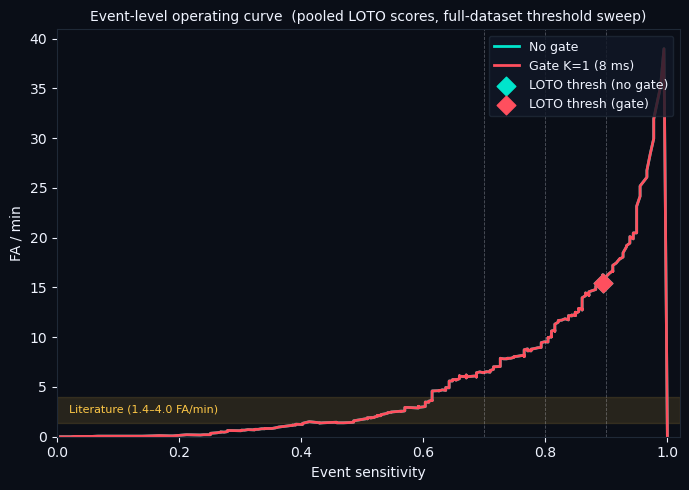

Saved → report/lgb_operating_curve.png

Operating threshold → 0.4970  (target EvtSens ≥ 70%)
  No gate : EvtSens=0.704  FA/min=6.5
  + gate  : EvtSens=0.704  FA/min=6.5  Latency=693 ms


In [15]:
%matplotlib inline

test_mask = np.isin(tid_all, TEST_TRIALS)
scores_test = res["scores"][test_mask]
scores_g_test = res["scores_gated"][test_mask]
ymom_test = y_mom[test_mask]

n_thr = 400
_lo = float(min(scores_test.min(), scores_g_test.min()))
_hi = float(max(scores_test.max(), scores_g_test.max()))
thresholds = np.linspace(_lo, _hi, n_thr)

sweep, sweep_g = [], []
for thr in thresholds:
    for sc, out in [(scores_test, sweep), (scores_g_test, sweep_g)]:
        e = event_detection_metrics(
            sc,
            ymom_test,
            threshold=thr,
            horizon=HORIZON,
            fs_eff=FS_EFF,
            refractory=REFRACTORY,
        )
        out.append(
            dict(
                thresh=thr,
                sens=e["event_sensitivity"],
                fa=e["fa_per_minute"],
                lat=e.get("mean_latency_ms", 0.0),
                n_det=e["n_detected"],
            )
        )

sens_arr = np.array([r["sens"] for r in sweep], dtype=np.float64)
fa_arr = np.array([r["fa"] for r in sweep], dtype=np.float64)
sens_g = np.array([r["sens"] for r in sweep_g], dtype=np.float64)
fa_g = np.array([r["fa"] for r in sweep_g], dtype=np.float64)


def best_at_sens(target, sw):
    """Highest threshold (= lowest FA/min) where EvtSens >= target."""
    cands = [r for r in sw if r["sens"] >= target]
    return max(cands, key=lambda r: r["thresh"]) if cands else None


# ── Operating-point table ─────────────────────────────────────────────────────
targets = [0.70, 0.75, 0.80, 0.85, 0.90]
print(
    f"{'EvtSens':>10}  {'FA/min':>10}  {'FA/min+gate':>12}  {'Latency+gate':>14}  {'Thresh+gate':>12}"
)
print("-" * 64)
for t in targets:
    ng = best_at_sens(t, sweep)
    g = best_at_sens(t, sweep_g)
    s_fa_ng = f"{ng['fa']:.1f}" if ng else "—"
    s_fa_g = f"{g['fa']:.1f}" if g else "—"
    s_lat = f"{g['lat']:.0f}" if g else "—"
    s_thr_g = f"{g['thresh']:.3f}" if g else "—"
    print(f"  >= {t:.0%}   {s_fa_ng:>10}  {s_fa_g:>12}  {s_lat:>14}  {s_thr_g:>12}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5), facecolor=DARK)
ax.set_facecolor(DARK)

ax.plot(sens_arr.tolist(), fa_arr.tolist(), color=TEAL, lw=2.0, label="No gate")
ax.plot(
    sens_g.tolist(),
    fa_g.tolist(),
    color=CORAL,
    lw=2.0,
    label=f"Gate K={PERSIST_K} ({PERSIST_K/FS_EFF*1000:.0f} ms)",
)

# Current LOTO-calibrated operating point
ax.scatter(
    [float(res["evt"]["event_sensitivity"])],
    [float(res["evt"]["fa_per_minute"])],
    color=TEAL,
    s=90,
    zorder=6,
    marker="D",
    label="LOTO thresh (no gate)",
)
ax.scatter(
    [float(res["evt_gated"]["event_sensitivity"])],
    [float(res["evt_gated"]["fa_per_minute"])],
    color=CORAL,
    s=90,
    zorder=6,
    marker="D",
    label="LOTO thresh (gate)",
)

# Literature benchmark band
ax.axhspan(1.4, 4.0, alpha=0.12, color=GOLD)
ax.text(
    0.02,
    2.7,
    "Literature (1.4–4.0 FA/min)",
    color=GOLD,
    fontsize=8,
    transform=ax.get_yaxis_transform(),
    va="center",
)

# Sensitivity guide lines
for sv in [0.70, 0.80, 0.90]:
    ax.axvline(sv, color=WHITE, lw=0.6, ls="--", alpha=0.3)

ax.set_xlabel("Event sensitivity", color=WHITE)
ax.set_ylabel("FA / min", color=WHITE)
ax.set_title(
    "Event-level operating curve  (pooled LOTO scores, full-dataset threshold sweep)",
    color=WHITE,
    fontsize=10,
)
ax.tick_params(colors=WHITE)
for sp in ax.spines.values():
    sp.set_edgecolor(EDGE)
ax.legend(
    facecolor=CARD, edgecolor=EDGE, labelcolor=WHITE, fontsize=9, loc="upper right"
)
ax.set_xlim(0, 1.02)
ax.set_ylim(bottom=0)
plt.tight_layout()

os.makedirs("report", exist_ok=True)
plt.savefig(
    "report/lgb_operating_curve.png", dpi=150, bbox_inches="tight", facecolor=DARK
)
plt.show()
print("Saved → report/lgb_operating_curve.png")

# ── Auto-select operating threshold at TARGET_EVT_SENS ──────────────────
_op_g = best_at_sens(TARGET_EVT_SENS, sweep_g)
if _op_g is not None:
    thresh = _op_g["thresh"]
    print(
        f"\nOperating threshold → {thresh:.4f}  (target EvtSens \u2265 {TARGET_EVT_SENS:.0%})"
    )
    evt = event_detection_metrics(
        scores_test,
        ymom_test,
        threshold=thresh,
        horizon=HORIZON,
        fs_eff=FS_EFF,
        refractory=REFRACTORY,
    )
    res["evt_gated"] = event_detection_metrics(
        scores_g_test,
        ymom_test,
        threshold=thresh,
        horizon=HORIZON,
        fs_eff=FS_EFF,
        refractory=REFRACTORY,
    )
    print(
        f"  No gate : EvtSens={evt['event_sensitivity']:.3f}  FA/min={evt['fa_per_minute']:.1f}"
    )
    print(
        f"  + gate  : EvtSens={res['evt_gated']['event_sensitivity']:.3f}  "
        f"FA/min={res['evt_gated']['fa_per_minute']:.1f}  "
        f"Latency={res['evt_gated'].get('mean_latency_ms', 0):.0f} ms"
    )
else:
    print(
        f"\n[warn] EvtSens \u2265 {TARGET_EVT_SENS:.0%} not achievable — keeping LOTO threshold ({thresh:.4f})"
    )

In [18]:
import pickle, os

# ── Save final model with operating-curve threshold ───────────────────────────
# thresh is set by the sweep in the cell above (TARGET_EVT_SENS operating point).
os.makedirs("models", exist_ok=True)

artifact = dict(
    model       = model_final,
    W           = W_final,
    USE_EA      = USE_EA,
    T_OPT       = T_OPT,
    FS          = FS,
    DECIM       = DECIM,
    FS_EFF      = FS_EFF,
    LP          = LP,
    HP          = HP,
    HORIZON     = HORIZON,
    SMOOTH_WIN  = SMOOTH_WIN,
    thresh      = thresh,
    REFRACTORY  = REFRACTORY,
    PERSIST_K   = PERSIST_K,
    mf_template = mf_template_final,
    EEG_COLS    = EEG_COLS,
)

save_path = f"models/lgb_s{SUBJECT}_{TACHE}.pkl"
with open(save_path, "wb") as fh:
    pickle.dump(artifact, fh)

print(f"Saved → {save_path}")
print(f"  Features={n_feat}  T_OPT={T_OPT} ({T_OPT/FS_EFF*1000:.0f} ms)  "
      f"thresh={thresh:.4f}  USE_EA={USE_EA}  USE_MF={USE_MF}  "
      f"target EvtSens ≥ {TARGET_EVT_SENS:.0%}")

Saved → models/lgb_s18_way.pkl
  Features=288  T_OPT=125 (1000 ms)  thresh=0.4970  USE_EA=False  USE_MF=False  target EvtSens ≥ 70%


## 9 · Trial Probability Timelines

Each panel shows one full LOTO trial (held-out, never seen during training):
- **Gold background** — true horizon label = 1 (press expected within 1 s)
- **Teal curve** — smoothed LightGBM probability
- **Coral dashed** — threshold (selected on training folds)
- **White verticals** — actual button press events

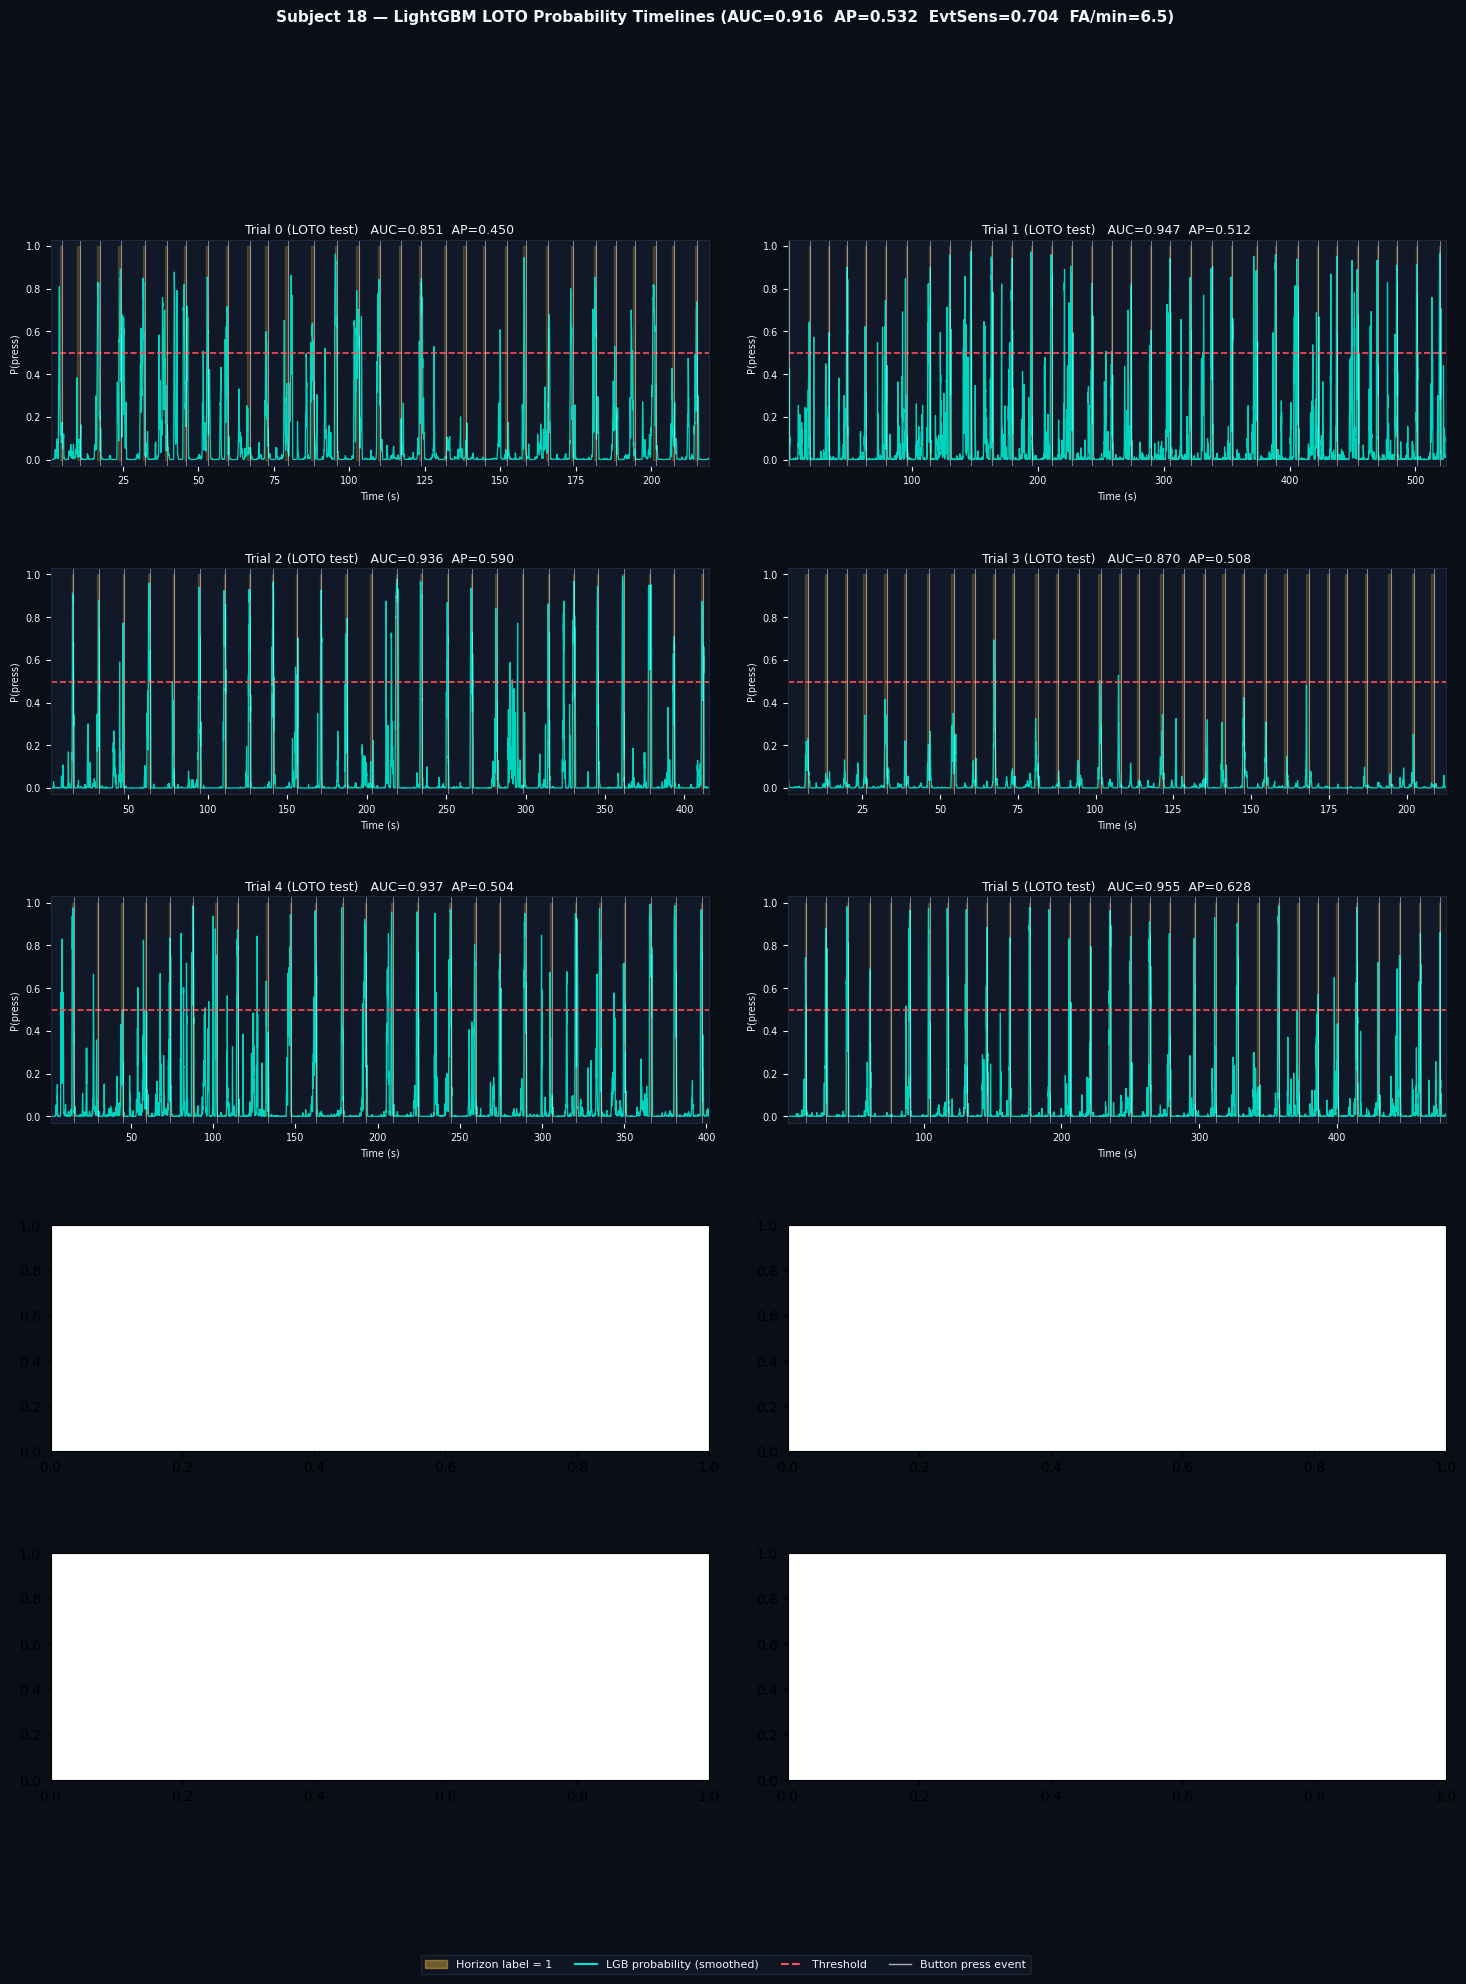

Saved → report/lgb_timelines.png


In [27]:
%matplotlib inline
os.makedirs("report", exist_ok=True)

fold_by_trial = {r["trial"]: r for r in fold_results}

fig, axes = plt.subplots(
    5, 2, figsize=(18, 20), facecolor=DARK, gridspec_kw=dict(hspace=0.45, wspace=0.12)
)

for idx, t in enumerate(ALL_TRIALS):
    ax = axes[idx // 2, idx % 2]
    ax.set_facecolor(CARD)
    for sp in ax.spines.values():
        sp.set_color(EDGE)
    ax.tick_params(colors=WHITE, labelsize=7)

    m = tid_all == t
    sc = scores_s[m]
    yl = y_all[m].astype(bool)
    n = m.sum()

    t_sec = (T_MAX + np.arange(n)) / FS_EFF

    ax.fill_between(
        t_sec, 0, 1, where=yl, color=GOLD, alpha=0.18, step="post", label="Label=1"
    )
    ax.plot(t_sec, sc, color=TEAL, lw=0.9, label="P(press)", alpha=0.92)
    ax.axhline(thresh, color=CORAL, lw=1.2, ls="--", label=f"Threshold {thresh:.3f}")

    _, _, y_mom_t = raw_data[t]
    press_samps = np.where(y_mom_t > 0)[0]
    for ps in press_samps:
        ps_time = ps / FS_EFF
        if t_sec[0] <= ps_time <= t_sec[-1]:
            ax.axvline(ps_time, color=WHITE, lw=0.6, alpha=0.55)

    if t in fold_by_trial:
        fold_auc = fold_by_trial[t]["auc"]
        fold_ap = fold_by_trial[t]["ap"]
        title_label = f"Trial {t} (LOTO test)   AUC={fold_auc:.3f}  AP={fold_ap:.3f}"
    else:
        title_label = f"Trial {t} (calibration — train only)"

    ax.set_title(title_label, color=WHITE, fontsize=9, pad=4)
    ax.set_xlim(t_sec[0], t_sec[-1])
    ax.set_ylim(-0.03, 1.03)
    ax.set_xlabel("Time (s)", color=WHITE, fontsize=7)
    ax.set_ylabel("P(press)", color=WHITE, fontsize=7)

handles = [
    mpatches.Patch(color=GOLD, alpha=0.4, label="Horizon label = 1"),
    plt.Line2D([0], [0], color=TEAL, lw=1.5, label="LGB probability (smoothed)"),
    plt.Line2D([0], [0], color=CORAL, lw=1.5, ls="--", label="Threshold"),
    plt.Line2D([0], [0], color=WHITE, lw=1.0, alpha=0.7, label="Button press event"),
]
fig.legend(
    handles=handles,
    loc="lower center",
    ncol=4,
    facecolor=CARD,
    labelcolor=WHITE,
    edgecolor=EDGE,
    fontsize=8,
    bbox_to_anchor=(0.5, 0.01),
)

fig.suptitle(
    f"Subject {SUBJECT} — LightGBM LOTO Probability Timelines "
    f'(AUC={res["auc"]:.3f}  AP={res["ap"]:.3f}  '
    f'EvtSens={evt["event_sensitivity"]:.3f}  '
    f'FA/min={evt["fa_per_minute"]:.1f})',
    color=WHITE,
    fontsize=11,
    y=0.995,
    fontweight="bold",
)

plt.savefig("report/lgb_timelines.png", dpi=120, bbox_inches="tight", facecolor=DARK)
plt.show()
print("Saved → report/lgb_timelines.png")

## 10 · Event-Related Probability (ERP-Style)

Average LightGBM probability locked to press events — the EEG analogue of an Event-Related Potential.
If the model captures the Bereitschaftspotential, the curve should **ramp upward ~1 s before the press**.
Detected and missed events are plotted separately to show what the model actually learned.

Events: 125 detected  53 missed  (total=178)


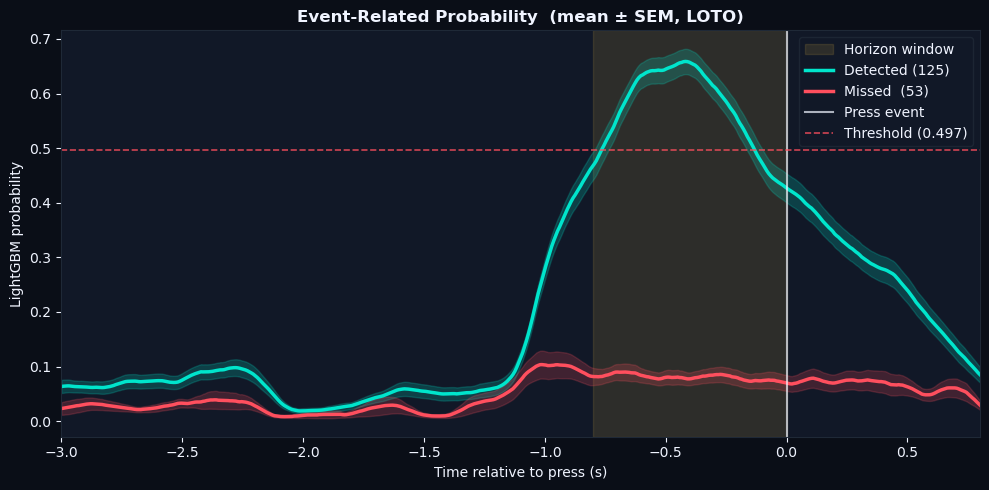

Saved → report/lgb_erp.png


In [20]:
%matplotlib inline

PRE_S, POST_S = 3.0, 0.8  # seconds before / after press
PRE = int(PRE_S * FS_EFF)
POST = int(POST_S * FS_EFF)
t_rel = np.linspace(-PRE_S, POST_S, PRE + POST)  # relative time axis

# Precompute trial start offset in the global scores array
trial_offset = {}
off = 0
for t in ALL_TRIALS:
    trial_offset[t] = off
    off += int((tid_all == t).sum())

erp_det, erp_mis = [], []  # detected / missed press events

for t in ALL_TRIALS:
    _, _, y_mom_t = raw_data[t]
    press_samps = np.where(y_mom_t > 0)[0]
    n_win_t = int((tid_all == t).sum())

    for ps in press_samps:
        win_k = ps - T_MAX  # index within this trial's windows
        if win_k < PRE or win_k + POST > n_win_t:
            continue
        gl_k = trial_offset[t] + win_k  # global index into scores_s
        epoch = scores_s[gl_k - PRE : gl_k + POST]
        if len(epoch) != PRE + POST:
            continue
        # Was this event detected? Check max score in horizon window
        win_start = max(0, gl_k - HORIZON)
        if scores_s[win_start : gl_k + 1].max() >= thresh:
            erp_det.append(epoch)
        else:
            erp_mis.append(epoch)

print(
    f"Events: {len(erp_det)} detected  {len(erp_mis)} missed  "
    f"(total={len(erp_det)+len(erp_mis)})"
)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5), facecolor=DARK)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)
ax.tick_params(colors=WHITE)

# HORIZON shading (-1 s to 0)
ax.axvspan(-HORIZON / FS_EFF, 0, color=GOLD, alpha=0.12, label="Horizon window")

for epochs, color, label in [
    (erp_det, TEAL, f"Detected ({len(erp_det)})"),
    (erp_mis, CORAL, f"Missed  ({len(erp_mis)})"),
]:
    if not epochs:
        continue
    arr = np.array(epochs)  # (N_events, T)
    mean = arr.mean(axis=0)
    sem = arr.std(axis=0) / np.sqrt(len(arr))
    ax.plot(t_rel, mean, color=color, lw=2.5, label=label)
    ax.fill_between(t_rel, mean - sem, mean + sem, color=color, alpha=0.2)

ax.axvline(0, color=WHITE, lw=1.5, ls="-", alpha=0.7, label="Press event")
ax.axhline(
    thresh, color=CORAL, lw=1.2, ls="--", alpha=0.8, label=f"Threshold ({thresh:.3f})"
)

ax.set_xlabel("Time relative to press (s)", color=WHITE)
ax.set_ylabel("LightGBM probability", color=WHITE)
ax.set_title(
    "Event-Related Probability  (mean ± SEM, LOTO)", color=WHITE, fontweight="bold"
)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE)
ax.set_xlim(-PRE_S, POST_S)

plt.tight_layout()
plt.savefig("report/lgb_erp.png", dpi=120, bbox_inches="tight", facecolor=DARK)
plt.show()
print("Saved → report/lgb_erp.png")

## 11 · Press Event Zoom Gallery

Each panel shows the 3.5 s window leading up to one individual press event.
**Green border** = detected (score ≥ threshold before press), **Red border** = missed.
The MRCP ramp should be visible as a rising probability in the last ~1 s before press.

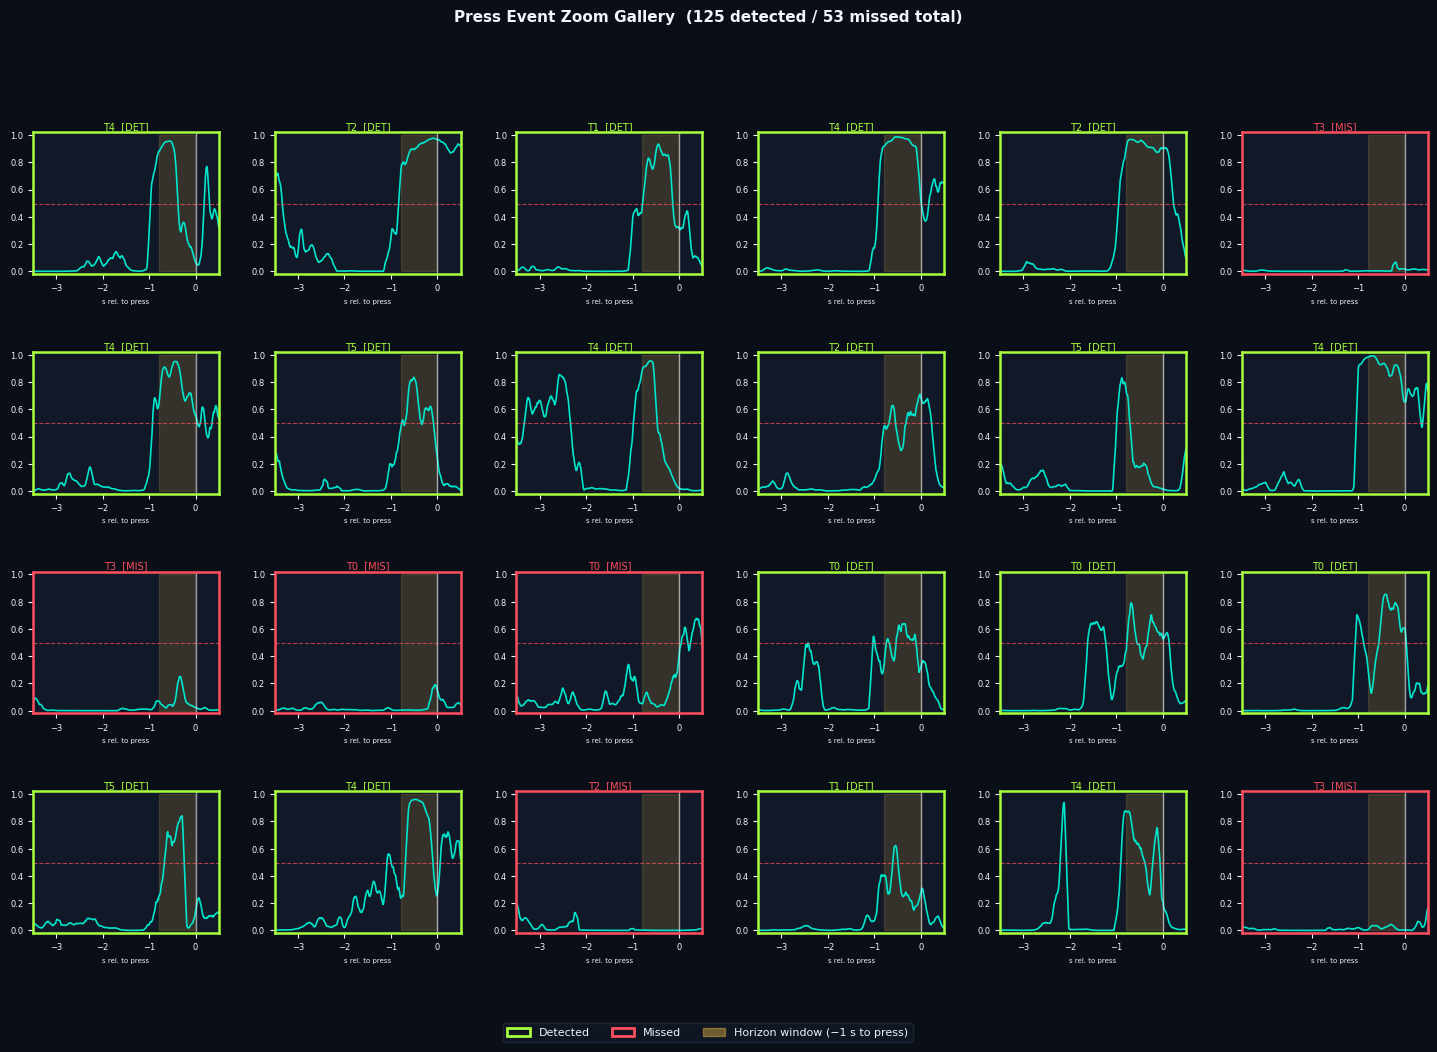

Saved → report/lgb_event_zoom.png  (24 events shown)


In [21]:
%matplotlib inline

ZOOM_PRE_S = 3.5
ZOOM_POST_S = 0.5
ZOOM_PRE = int(ZOOM_PRE_S * FS_EFF)
ZOOM_POST = int(ZOOM_POST_S * FS_EFF)
t_zoom_rel = np.linspace(-ZOOM_PRE_S, ZOOM_POST_S, ZOOM_PRE + ZOOM_POST)

# Collect individual press event windows
events = []  # list of (epoch, detected, trial)
for t in ALL_TRIALS:
    _, _, y_mom_t = raw_data[t]
    press_samps = np.where(y_mom_t > 0)[0]
    n_win_t = int((tid_all == t).sum())
    for ps in press_samps:
        win_k = ps - T_MAX
        if win_k < ZOOM_PRE or win_k + ZOOM_POST > n_win_t:
            continue
        gl_k = trial_offset[t] + win_k
        epoch = scores_s[gl_k - ZOOM_PRE : gl_k + ZOOM_POST]
        if len(epoch) != ZOOM_PRE + ZOOM_POST:
            continue
        win_start = max(0, gl_k - HORIZON)
        detected = bool(scores_s[win_start : gl_k + 1].max() >= thresh)
        events.append((epoch, detected, t))

# Sample up to N_SHOW events (equal split detected / missed where possible)
N_SHOW = 24
det_ev = [(e, True, t) for e, d, t in events if d]
mis_ev = [(e, False, t) for e, d, t in events if not d]
rng = np.random.default_rng(SEED)
n_det = min(len(det_ev), N_SHOW * 3 // 4)
n_mis = min(len(mis_ev), N_SHOW - n_det)
sel_det = [det_ev[i] for i in rng.choice(len(det_ev), n_det, replace=False)]
sel_mis = [mis_ev[i] for i in rng.choice(len(mis_ev), n_mis, replace=False)]
sel = sel_det + sel_mis
rng.shuffle(sel)

ncols = 6
nrows = (len(sel) + ncols - 1) // ncols
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(ncols * 3, nrows * 2.6),
    facecolor=DARK,
    gridspec_kw=dict(hspace=0.55, wspace=0.3),
)
axes = axes.flatten()

for i, (epoch, detected, t_id) in enumerate(sel):
    ax = axes[i]
    ax.set_facecolor(CARD)
    for sp in ax.spines.values():
        sp.set_color(LIME if detected else CORAL)
        sp.set_linewidth(1.8)
    ax.tick_params(colors=WHITE, labelsize=6)

    ax.fill_between(
        t_zoom_rel,
        0,
        1,
        where=(t_zoom_rel >= -HORIZON / FS_EFF) & (t_zoom_rel <= 0),
        color=GOLD,
        alpha=0.15,
    )
    ax.plot(t_zoom_rel, epoch, color=TEAL, lw=1.2)
    ax.axhline(thresh, color=CORAL, lw=0.8, ls="--", alpha=0.7)
    ax.axvline(0, color=WHITE, lw=1.0, ls="-", alpha=0.6)

    status = "DET" if detected else "MIS"
    ax.set_title(
        f"T{t_id}  [{status}]", color=LIME if detected else CORAL, fontsize=7, pad=2
    )
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlim(-ZOOM_PRE_S, ZOOM_POST_S)
    ax.set_xlabel("s rel. to press", color=WHITE, fontsize=5)

# Hide unused axes
for j in range(len(sel), len(axes)):
    axes[j].set_visible(False)

legend_handles = [
    mpatches.Patch(edgecolor=LIME, facecolor="none", lw=2, label="Detected"),
    mpatches.Patch(edgecolor=CORAL, facecolor="none", lw=2, label="Missed"),
    mpatches.Patch(color=GOLD, alpha=0.4, label="Horizon window (−1 s to press)"),
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    facecolor=CARD,
    labelcolor=WHITE,
    edgecolor=EDGE,
    fontsize=8,
    bbox_to_anchor=(0.5, 0.0),
)

fig.suptitle(
    f"Press Event Zoom Gallery  ({len(det_ev)} detected / {len(mis_ev)} missed total)",
    color=WHITE,
    fontsize=11,
    fontweight="bold",
    y=0.998,
)

plt.savefig("report/lgb_event_zoom.png", dpi=120, bbox_inches="tight", facecolor=DARK)
plt.show()
print(f"Saved → report/lgb_event_zoom.png  ({len(sel)} events shown)")

## 12 · Per-Fold Metrics

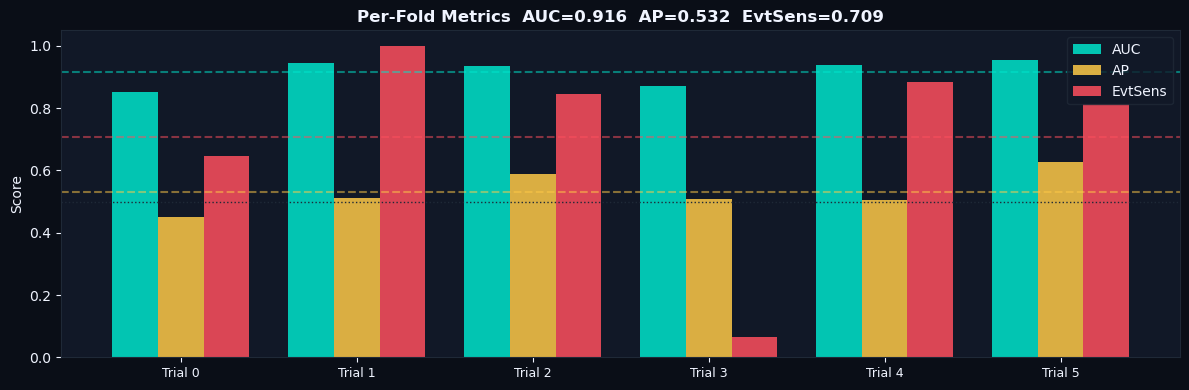

In [22]:
%matplotlib inline

trials = [r["trial"] for r in fold_results]
aucs = [r["auc"] for r in fold_results]
aps = [r["ap"] for r in fold_results]

# Per-trial event sensitivity (requires per-trial computation)
evt_sens_per_trial = []
for t in TEST_TRIALS:
    m = tid_all == t
    sc_t = scores_s[m]
    ym_t = y_mom[m]
    e = event_detection_metrics(
        sc_t,
        ym_t,
        threshold=thresh,
        horizon=HORIZON,
        fs_eff=FS_EFF,
        refractory=REFRACTORY,
    )
    evt_sens_per_trial.append(e["event_sensitivity"])

x = np.arange(len(trials))
w = 0.26
fig, ax = plt.subplots(figsize=(12, 4), facecolor=DARK)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)
ax.tick_params(colors=WHITE)

ax.bar(x - w, aucs, width=w, color=TEAL, alpha=0.85, label="AUC")
ax.bar(x, aps, width=w, color=GOLD, alpha=0.85, label="AP")
ax.bar(x + w, evt_sens_per_trial, width=w, color=CORAL, alpha=0.85, label="EvtSens")

ax.axhline(np.mean(aucs), color=TEAL, lw=1.5, ls="--", alpha=0.5)
ax.axhline(np.mean(aps), color=GOLD, lw=1.5, ls="--", alpha=0.5)
ax.axhline(np.mean(evt_sens_per_trial), color=CORAL, lw=1.5, ls="--", alpha=0.5)
ax.axhline(0.5, color=EDGE, lw=1, ls=":")

ax.set_xticks(x)
ax.set_xticklabels([f"Trial {t}" for t in trials], color=WHITE, fontsize=9)
ax.set_ylabel("Score", color=WHITE)
ax.set_title(
    f"Per-Fold Metrics  "
    f"AUC={np.mean(aucs):.3f}  AP={np.mean(aps):.3f}  "
    f"EvtSens={np.mean(evt_sens_per_trial):.3f}",
    color=WHITE,
    fontweight="bold",
)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("report/lgb_per_fold.png", dpi=120, bbox_inches="tight", facecolor=DARK)
plt.show()

## 13 · ROC & Precision-Recall Curves

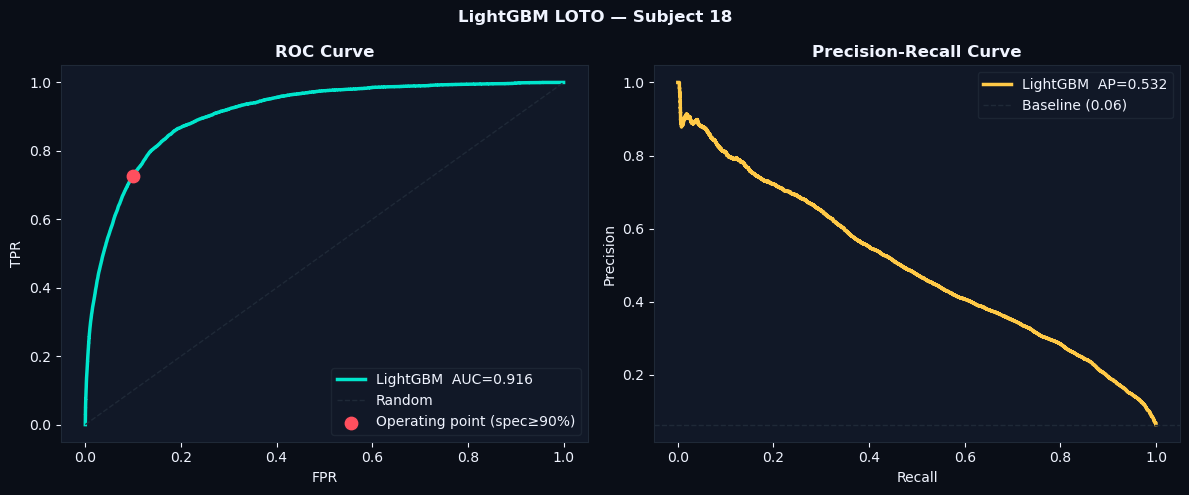

In [23]:
%matplotlib inline
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 5), facecolor=DARK)

for ax in (ax_roc, ax_pr):
    ax.set_facecolor(CARD)
    for sp in ax.spines.values():
        sp.set_color(EDGE)
    ax.tick_params(colors=WHITE)

# ROC
fpr, tpr, _ = roc_curve(y_all, scores_s)
ax_roc.plot(fpr, tpr, color=TEAL, lw=2.5, label=f'LightGBM  AUC={res["auc"]:.3f}')
ax_roc.plot([0, 1], [0, 1], color=EDGE, lw=1, ls="--", label="Random")

# Mark operating point at chosen threshold
op_fpr = 1 - MIN_SPEC
op_idx = np.argmin(np.abs(fpr - op_fpr))
ax_roc.scatter(
    fpr[op_idx],
    tpr[op_idx],
    color=CORAL,
    s=80,
    zorder=5,
    label=f"Operating point (spec≥{MIN_SPEC:.0%})",
)

ax_roc.set_xlabel("FPR", color=WHITE)
ax_roc.set_ylabel("TPR", color=WHITE)
ax_roc.set_title("ROC Curve", color=WHITE, fontweight="bold")
ax_roc.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE)

# PR
prec, rec, _ = precision_recall_curve(y_all, scores_s)
baseline_pr = y_all.mean()
ax_pr.plot(rec, prec, color=GOLD, lw=2.5, label=f'LightGBM  AP={res["ap"]:.3f}')
ax_pr.axhline(
    baseline_pr, color=EDGE, lw=1, ls="--", label=f"Baseline ({baseline_pr:.2f})"
)

ax_pr.set_xlabel("Recall", color=WHITE)
ax_pr.set_ylabel("Precision", color=WHITE)
ax_pr.set_title("Precision-Recall Curve", color=WHITE, fontweight="bold")
ax_pr.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE)

plt.suptitle(
    f"LightGBM LOTO — Subject {SUBJECT}", color=WHITE, fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("report/lgb_roc_pr.png", dpi=120, bbox_inches="tight", facecolor=DARK)
plt.show()

## 14 · Feature Importance

Top features averaged and std-ranked across 10 LOTO folds.
Feature names encode channel and feature type: `ch{N}_{feature}`.

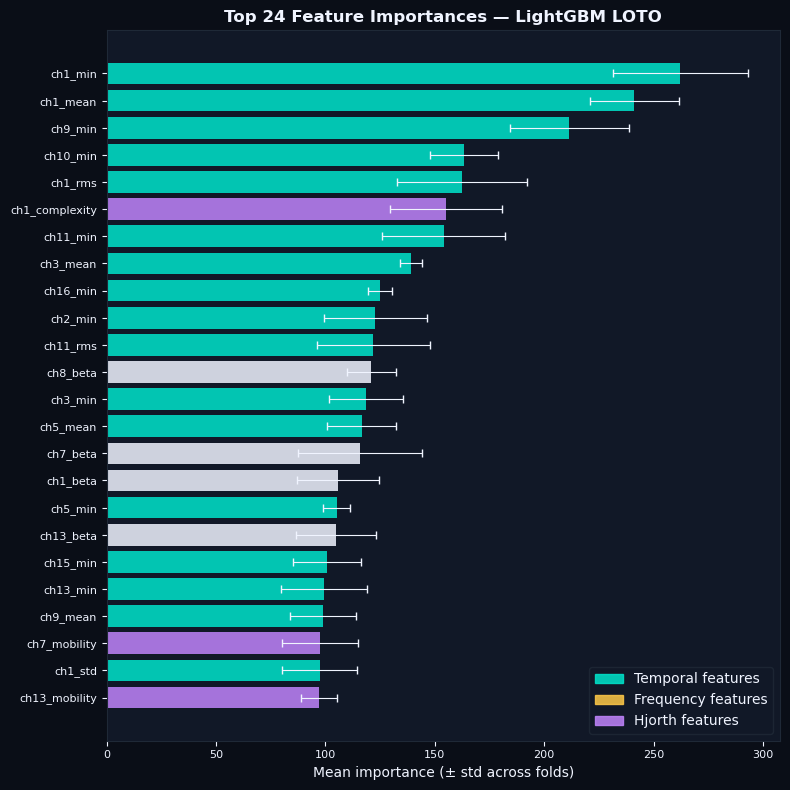

Saved → report/lgb_importance.png


In [24]:
%matplotlib inline
TOP_N = 24

order = np.argsort(mean_imp)[::-1][:TOP_N]
imp_top = mean_imp[order]
std_top = std_imp[order]
names = [FEAT_NAMES[i] for i in order]

family_colors = {
    "mean": TEAL,
    "std": TEAL,
    "slope": TEAL,
    "min": TEAL,
    "argmin": TEAL,
    "rms": TEAL,
    "delta": GOLD,
    "theta": GOLD,
    "entropy": GOLD,
    "activity": PURPLE,
    "mobility": PURPLE,
    "complexity": PURPLE,
}
bar_colors = [family_colors.get(n.split("_", 1)[1], WHITE) for n in names]

fig, ax = plt.subplots(figsize=(8, 8), facecolor=DARK)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)
ax.tick_params(colors=WHITE, labelsize=8)

y_pos = np.arange(TOP_N)
ax.barh(
    y_pos,
    imp_top[::-1],
    xerr=std_top[::-1],
    color=bar_colors[::-1],
    alpha=0.85,
    error_kw=dict(ecolor=WHITE, capsize=3, lw=0.8),
)

ax.set_yticks(y_pos)
ax.set_yticklabels(names[::-1], fontsize=8, color=WHITE)
ax.set_xlabel("Mean importance (± std across folds)", color=WHITE)
ax.set_title(
    f"Top {TOP_N} Feature Importances — LightGBM LOTO", color=WHITE, fontweight="bold"
)

legend_handles = [
    mpatches.Patch(color=TEAL, alpha=0.85, label="Temporal features"),
    mpatches.Patch(color=GOLD, alpha=0.85, label="Frequency features"),
    mpatches.Patch(color=PURPLE, alpha=0.85, label="Hjorth features"),
]
ax.legend(handles=legend_handles, facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE)

plt.tight_layout()
plt.savefig("report/lgb_importance.png", dpi=120, bbox_inches="tight", facecolor=DARK)
plt.show()
print("Saved → report/lgb_importance.png")

IndexError: index 288 is out of bounds for axis 0 with size 288

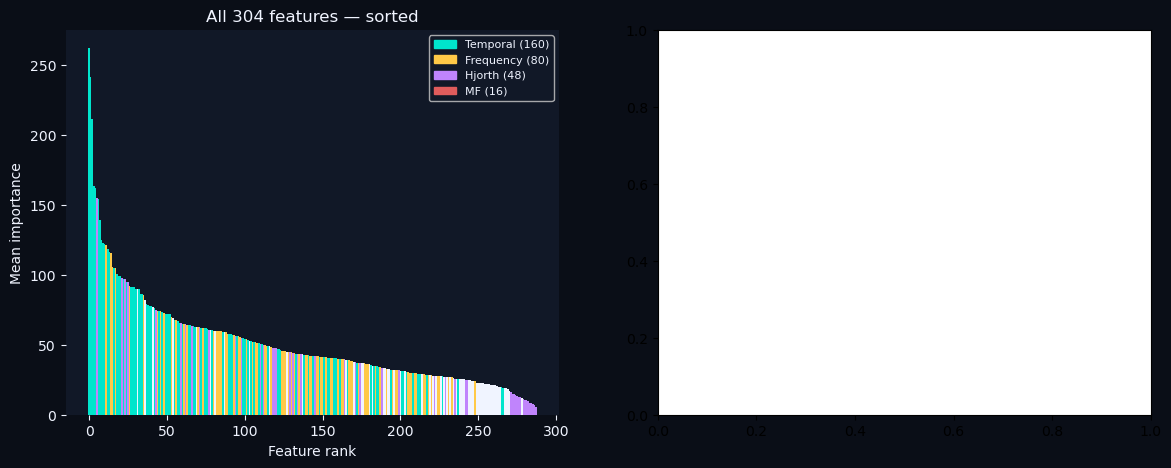

In [25]:
%matplotlib inline

# Full 304-feature importance distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK)

# --- Left: sorted bar of all features, coloured by family ---
all_order = np.argsort(mean_imp)[::-1]
family_map = {
    "mean": TEAL, "std": TEAL, "slope": TEAL, "min": TEAL,
    "argmin": TEAL, "rms": TEAL, "seg0": TEAL, "seg1": TEAL,
    "seg2": TEAL, "seg3": TEAL,
    "delta": GOLD, "theta": GOLD, "alpha": GOLD, "beta": GOLD, "entropy": GOLD,
    "activity": PURPLE, "mobility": PURPLE, "complexity": PURPLE,
    "mf": "#e05c5c",
}
bar_c = [family_map.get(FEAT_NAMES[i].split("_", 1)[1], WHITE) for i in all_order]

ax = axes[0]
ax.set_facecolor(CARD)
ax.bar(np.arange(len(mean_imp)), mean_imp[all_order], color=bar_c, width=1.0, linewidth=0)
ax.set_xlabel("Feature rank", color=WHITE)
ax.set_ylabel("Mean importance", color=WHITE)
ax.set_title("All 304 features — sorted", color=WHITE)
ax.tick_params(colors=WHITE)
for sp in ax.spines.values():
    sp.set_visible(False)

# legend
from matplotlib.patches import Patch
legend_items = [
    Patch(color=TEAL,     label=f"Temporal ({N_CH*10})"),
    Patch(color=GOLD,     label=f"Frequency ({N_CH*5})"),
    Patch(color=PURPLE,   label=f"Hjorth ({N_CH*3})"),
    Patch(color="#e05c5c",label=f"MF ({N_CH})"),
]
ax.legend(handles=legend_items, facecolor=CARD, labelcolor=WHITE, fontsize=8)

# --- Right: per-family aggregate importance ---
families = {
    "Temporal": [i for i, n in enumerate(FEAT_NAMES) if n.split("_",1)[1] in
                 ("mean","std","slope","min","argmin","rms","seg0","seg1","seg2","seg3")],
    "Delta":    [i for i, n in enumerate(FEAT_NAMES) if "delta"    in n],
    "Theta":    [i for i, n in enumerate(FEAT_NAMES) if "theta"    in n],
    "Alpha":    [i for i, n in enumerate(FEAT_NAMES) if "alpha"    in n],
    "Beta":     [i for i, n in enumerate(FEAT_NAMES) if "beta"     in n],
    "Entropy":  [i for i, n in enumerate(FEAT_NAMES) if "entropy"  in n],
    "Hjorth":   [i for i, n in enumerate(FEAT_NAMES) if n.split("_",1)[1] in
                 ("activity","mobility","complexity")],
    "MF":       [i for i, n in enumerate(FEAT_NAMES) if "mf"       in n],
}
fam_names = list(families.keys())
fam_totals = [mean_imp[idx].sum() for idx in families.values()]
fam_colors = [TEAL, GOLD, GOLD, GOLD, GOLD, GOLD, PURPLE, "#e05c5c"]

ax2 = axes[1]
ax2.set_facecolor(CARD)
bars = ax2.barh(fam_names, fam_totals, color=fam_colors)
ax2.set_xlabel("Total importance (sum)", color=WHITE)
ax2.set_title("Per-family aggregate", color=WHITE)
ax2.tick_params(colors=WHITE)
for sp in ax2.spines.values():
    sp.set_visible(False)
for bar, val in zip(bars, fam_totals):
    ax2.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", color=WHITE, fontsize=8)

fig.tight_layout()
plt.show()

# Print zero/near-zero count per family
print("Features with importance < 0.001:")
for name, idx in families.items():
    n_low = (mean_imp[idx] < 0.001).sum()
    print(f"  {name:10s}: {n_low}/{len(idx)} near-zero")


## 15 · Detection Latency Distribution

For every detected press event, how many milliseconds *before* the press did the model first cross the threshold?  A distribution peaking near −500 ms confirms anticipatory detection, not reactive detection.

In [ ]:
%matplotlib inline

latencies_ms = []

for t in TEST_TRIALS:
    _, _, y_mom_t = raw_data[t]
    press_samps = np.where(y_mom_t > 0)[0]
    n_win_t = int((tid_all == t).sum())

    for ps in press_samps:
        win_k = ps - T_MAX
        if win_k < 1 or win_k >= n_win_t:
            continue
        gl_k = trial_offset[t] + win_k
        # Search backwards from press for first threshold crossing
        look_back = min(win_k, HORIZON)
        window = scores_s[gl_k - look_back : gl_k + 1]
        crossings = np.where(window >= thresh)[0]
        if len(crossings) == 0:
            continue  # missed event — skip
        # First crossing relative to press (negative = before)
        first_cross = crossings[0] - look_back  # ≤ 0
        latencies_ms.append(first_cross / FS_EFF * 1000)

latencies_ms = np.array(latencies_ms)
print(f"Detected events with latency data: {len(latencies_ms)}")
print(f"Median latency : {np.median(latencies_ms):.0f} ms")
print(f"Mean latency   : {np.mean(latencies_ms):.0f} ms")

fig, ax = plt.subplots(figsize=(9, 4), facecolor=DARK)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)
ax.tick_params(colors=WHITE)

bins = np.linspace(-HORIZON / FS_EFF * 1000, 100, 40)
ax.hist(latencies_ms, bins=bins, color=TEAL, alpha=0.85, edgecolor=DARK, lw=0.5)
ax.axvline(
    np.median(latencies_ms),
    color=CORAL,
    lw=2,
    ls="--",
    label=f"Median {np.median(latencies_ms):.0f} ms",
)
ax.axvline(0, color=WHITE, lw=1, ls="-", alpha=0.5, label="Press moment")

ax.set_xlabel("Detection latency (ms, negative = before press)", color=WHITE)
ax.set_ylabel("Count", color=WHITE)
ax.set_title(
    "Detection Latency Distribution  (anticipatory = negative)",
    color=WHITE,
    fontweight="bold",
)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE)

plt.tight_layout()
plt.savefig("report/lgb_latency.png", dpi=120, bbox_inches="tight", facecolor=DARK)
plt.show()
print("Saved → report/lgb_latency.png")

## 16 · Summary

In [17]:
e = evt
eg = res["evt_gated"]
print("=" * 60)
print(f"  LightGBM + Eng Features — Subject {SUBJECT}  LOTO CV")
print("=" * 60)
print(
    f"  Features       : {N_CH*10 + N_CH*5 + N_CH*3 + N_CH}  (temporal {N_CH*10} + freq {N_CH*5} + Hjorth {N_CH*3} + MF {N_CH})"
)
print(f"  Window (T_OPT) : {T_OPT/FS_EFF:.2f} s ({T_OPT} samples @ {FS_EFF} Hz)")
print(
    f"  Horizon        : {HORIZON/FS_EFF*1000:.0f} ms  Smooth: {SMOOTH_WIN/FS_EFF*1000:.0f} ms"
)
print(
    f"  Refractory     : {REFRACTORY/FS_EFF*1000:.0f} ms   Persist gate: {PERSIST_K} samp = {PERSIST_K/FS_EFF*1000:.0f} ms"
)
print(f"  Threshold      : {thresh:.4f}  (spec ≥ {MIN_SPEC:.0%}, CV-tuned)")
print()
print(f"  {'Metric':<20} {'No gate':>10}  {'+ gate':>10}")
print(f"  {'-'*42}")
print(f"  {'LOTO AUC':<20} {res['auc']:>10.4f}")
print(f"  {'LOTO AP':<20} {res['ap']:>10.4f}")
print(
    f"  {'Event sens.':<20} {e['event_sensitivity']:>10.3f}  {eg['event_sensitivity']:>10.3f}"
)
print(f"  {'FA / min':<20} {e['fa_per_minute']:>10.1f}  {eg['fa_per_minute']:>10.1f}")
print(
    f"  {'Mean latency (ms)':<20} {e.get('mean_latency_ms', 0):>10.1f}  {eg.get('mean_latency_ms', 0):>10.1f}"
)
print(
    f"  {'Events detected':<20} {e['n_detected']:>5}/{e['n_events']:<4}   {eg['n_detected']:>5}/{eg['n_events']:<4}"
)
print("=" * 60)
print()
print("Saved plots:")
for fname in [
    "lgb_timelines",
    "lgb_erp",
    "lgb_event_zoom",
    "lgb_per_fold",
    "lgb_roc_pr",
    "lgb_importance",
    "lgb_latency",
]:
    p = f"report/{fname}.png"
    exists = os.path.exists(p)

  LightGBM + Eng Features — Subject 18  LOTO CV
  Features       : 304  (temporal 160 + freq 80 + Hjorth 48 + MF 16)
  Window (T_OPT) : 1.00 s (125 samples @ 125 Hz)
  Horizon        : 800 ms  Smooth: 96 ms
  Refractory     : 8 ms   Persist gate: 1 samp = 8 ms
  Threshold      : 0.4970  (spec ≥ 90%, CV-tuned)

  Metric                  No gate      + gate
  ------------------------------------------
  LOTO AUC                 0.9161
  LOTO AP                  0.5322
  Event sens.               0.704       0.704
  FA / min                    6.5         6.5
  Mean latency (ms)         693.0       693.0
  Events detected        126/179      126/179 

Saved plots:
